# Pandas Data Manipulation & Visualization — Practice (QUESTIONS)

This notebook covers practical, **interview-friendly** pandas exercises:

1. Import & Export CSV files
2. Selecting Rows & Columns
3. Filter DataFrame — where, query
4. DataFrame Operations — Add, Update, Delete, Sort Values
5. Handling Date Values
6. Handling Missing Values
7. Aggregation and Group By
8. Concatenate & Merge DataFrames (JOINs)
9. Data Visualization — Matplotlib & Seaborn

**Total practice problems: 60**

### Datasets used (in the `data/` folder)
- `employees.csv` — 150 employees with intentionally messy dates, missing salaries/bonuses/ratings
- `departments.csv` — department metadata (intentionally missing the `Support` department, for join practice)
- `sales_q1.csv`, `sales_q2.csv` — two quarters of sales data (identical schema, for `concat` practice; also contains a couple of invalid `EmpID`s for merge practice)

> Each question has an empty code cell below it — write your solution there. Work through the topics **in order** since later sections build on columns created earlier (e.g. Section 5 converts `JoinDate`, and later sections use it).

---
## 0. Setup & Creating DataFrames

Before working with the datasets, import the libraries you'll need and warm up by creating small DataFrames from scratch — a very common interview opener.

**Q0.1** Import `pandas` as `pd`, `numpy` as `np`, `matplotlib.pyplot` as `plt`, and `seaborn` as `sns`. Also run `%matplotlib inline` and set `sns.set_style('whitegrid')`.

In [162]:
# Your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style('whitegrid')

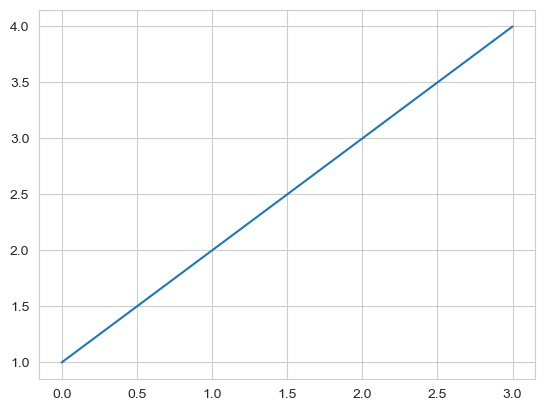

In [163]:
plt.plot([1,2,3,4])
plt.show()

**Q0.2** Create a DataFrame `df_manual` from a **dictionary of lists** with columns `Name`, `Age`, `City` for 4 people of your choice.

In [164]:
data = {
     "Name":["Rahul","Priya","Rohit","Neha"],
    "Age":[23,32,43,26],
    "City":["Pune","Mumbai","Goa","Nagpur"]
}
df_manual = pd.DataFrame(data)
df_manual

,Name,Age,City
0,Rahul,23,Pune
1,Priya,32,Mumbai
2,Rohit,43,Goa
3,Neha,26,Nagpur


In [165]:
# Your code here
df_manual = pd.DataFrame({
    "Name":["Rahul","Priya","Rohit","Neha"],
    "Age":[23,32,43,26],
    "City":["Pune","Mumbai","Goa","Nagpur"]
})
df_manual

,Name,Age,City
0,Rahul,23,Pune
1,Priya,32,Mumbai
2,Rohit,43,Goa
3,Neha,26,Nagpur


In [166]:
df_manual["Marks"] = [45,55,35,40]
df_manual

,Name,Age,City,Marks
0,Rahul,23,Pune,45
1,Priya,32,Mumbai,55
2,Rohit,43,Goa,35
3,Neha,26,Nagpur,40


In [167]:
df_manual.loc[len(df_manual)] = ["Priya",34,"Pune",56]
df_manual

,Name,Age,City,Marks
0,Rahul,23,Pune,45
1,Priya,32,Mumbai,55
2,Rohit,43,Goa,35
3,Neha,26,Nagpur,40
4,Priya,34,Pune,56


**Q0.3** Create the same kind of DataFrame but this time from a **list of dictionaries** (each dictionary = one row). Call it `df_manual2`.

In [168]:
# Your code here
data = [
    {"Name":"Pooja","Age":50,"City":"Pune"},
    {"Name":"Neha","Age":45,"City":"Mumbai"},
    {"Name":"Rahul","Age":34,"City":"Nagpur"},
    {"Name":"Rohit","Age":76,"City":"Goa"}
]
df_manual2 = pd.DataFrame(data)
df_manual2

,Name,Age,City
0,Pooja,50,Pune
1,Neha,45,Mumbai
2,Rahul,34,Nagpur
3,Rohit,76,Goa


In [169]:
df_manual2["Course"] = ["Python","Java","Q","r"]

In [170]:
df_manual2

,Name,Age,City,Course
0,Pooja,50,Pune,Python
1,Neha,45,Mumbai,Java
2,Rahul,34,Nagpur,Q
3,Rohit,76,Goa,r


In [171]:
df_manual2.loc[4] = ["Pooja",23,"Chennai","Python"]

**Q0.4** For `df_manual`, print `.shape`, `.dtypes`, `.info()`, and `.describe()`. *(Interview tip: know the difference between `.info()` and `.describe()`.)*

In [172]:
# Your code here
print("Dimensions:",df_manual.shape)
print("\nDtypes:",df_manual.dtypes)

Dimensions: (5, 4)

Dtypes: Name     object
Age       int64
City     object
Marks     int64
dtype: object


In [173]:
df_manual.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    5 non-null      object
 1   Age     5 non-null      int64 
 2   City    5 non-null      object
 3   Marks   5 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 200.0+ bytes


In [174]:
df_manual.describe()

,Age,Marks
count,5.000000,5.00000
mean,31.600000,46.20000
std,7.765307,9.20326
min,23.000000,35.00000
25%,26.000000,40.00000
50%,32.000000,45.00000
75%,34.000000,55.00000
max,43.000000,56.00000


---
## 1. Import & Export CSV Files

You have 4 CSV files  `employees.csv`, `departments.csv`, `sales_q1.csv`, and `sales_q2.csv`. Use them for this section.

**Q1.1** Read `\employees.csv` into a DataFrame called `emp`. Display the first 5 rows.

In [175]:
# Your code here
import pandas as pd
emp = pd.read_csv("Employees.csv")
emp.head()

,EmpID,Name,Department,City,JoinDate,Age,Gender,Salary,Bonus,Rating
0,1001,Reyansh Shetty,Marketing,Chennai,45-13-2021,31,M,48574.0,2625.0,3.9
1,1002,Sneha Malhotra,Finance,Mumbai,2019-12-16,40,F,39184.0,11314.0,2.2
2,1003,Ananya Patel,IT,Delhi,2021-10-28,38,F,49096.0,8973.0,3.3
3,1004,Sneha Menon,IT,Chennai,2023-01-02,42,F,97728.0,9577.0,2.9
4,1005,Priya Pillai,Finance,Bangalore,2018-04-20,35,M,64016.0,9070.0,3.7


**Q1.2** Read only the **first 10 rows** of `employees.csv` (without loading the whole file) into `emp_top10`.

In [176]:
# Your code here
emp = pd.read_csv("Employees.csv",nrows=10)
emp

,EmpID,Name,Department,City,JoinDate,Age,Gender,Salary,Bonus,Rating
0,1001,Reyansh Shetty,Marketing,Chennai,45-13-2021,31,M,48574.0,2625.0,3.9
1,1002,Sneha Malhotra,Finance,Mumbai,2019-12-16,40,F,39184.0,11314.0,2.2
2,1003,Ananya Patel,IT,Delhi,2021-10-28,38,F,49096.0,8973.0,3.3
3,1004,Sneha Menon,IT,Chennai,2023-01-02,42,F,97728.0,9577.0,2.9
4,1005,Priya Pillai,Finance,Bangalore,2018-04-20,35,M,64016.0,9070.0,3.7
5,1006,Aman Kumar,IT,Chennai,2021-01-23,30,F,41246.0,NaN,NaN
6,1007,Ananya Iyer,IT,Chennai,2015-04-01,22,M,75558.0,4600.0,3.9
7,1008,Ayaan Gupta,Sales,Mumbai,2016-12-14,34,M,148721.0,7783.0,1.9
8,1009,Karan Verma,Finance,Bangalore,2020-02-25,25,M,48381.0,14226.0,1.1
9,1010,Nikhil Das,Finance,Chennai,2015-02-08,22,M,66455.0,10146.0,2.0


**Q1.3** Read `employees.csv` but load **only** the columns `EmpID`, `Name`, `Salary` into `emp_small`.

In [177]:
# Your code here
emp = pd.read_csv("Employees.csv",usecols=["EmpID","Name","Salary"])
emp.head()

,EmpID,Name,Salary
0,1001,Reyansh Shetty,48574.0
1,1002,Sneha Malhotra,39184.0
2,1003,Ananya Patel,49096.0
3,1004,Sneha Menon,97728.0
4,1005,Priya Pillai,64016.0


**Q1.4** Read `employees.csv` again, this time setting `EmpID` as the index column directly while reading. Call it `emp_indexed`.

In [178]:
# Your code herei
emp = pd.read_csv("Employees.csv")
emp.head()

,EmpID,Name,Department,City,JoinDate,Age,Gender,Salary,Bonus,Rating
0,1001,Reyansh Shetty,Marketing,Chennai,45-13-2021,31,M,48574.0,2625.0,3.9
1,1002,Sneha Malhotra,Finance,Mumbai,2019-12-16,40,F,39184.0,11314.0,2.2
2,1003,Ananya Patel,IT,Delhi,2021-10-28,38,F,49096.0,8973.0,3.3
3,1004,Sneha Menon,IT,Chennai,2023-01-02,42,F,97728.0,9577.0,2.9
4,1005,Priya Pillai,Finance,Bangalore,2018-04-20,35,M,64016.0,9070.0,3.7


**Q1.5** From `emp`, filter employees with `Salary > 100000` and export the result to `output/high_earners.csv` **without** writing the index column.

In [179]:
emp.head()

,EmpID,Name,Department,City,JoinDate,Age,Gender,Salary,Bonus,Rating
0,1001,Reyansh Shetty,Marketing,Chennai,45-13-2021,31,M,48574.0,2625.0,3.9
1,1002,Sneha Malhotra,Finance,Mumbai,2019-12-16,40,F,39184.0,11314.0,2.2
2,1003,Ananya Patel,IT,Delhi,2021-10-28,38,F,49096.0,8973.0,3.3
3,1004,Sneha Menon,IT,Chennai,2023-01-02,42,F,97728.0,9577.0,2.9
4,1005,Priya Pillai,Finance,Bangalore,2018-04-20,35,M,64016.0,9070.0,3.7


In [180]:
# Your code here
high_earners = emp[emp["Salary"] >100000]
high_earners.to_csv("high_earners.csv",index=False)
high_earners.head()

,EmpID,Name,Department,City,JoinDate,Age,Gender,Salary,Bonus,Rating
7,1008,Ayaan Gupta,Sales,Mumbai,2016-12-14,34,M,148721.0,7783.0,1.9
10,1011,Kavya Nair,HR,Delhi,2023-10-03,53,M,122263.0,5971.0,3.4
17,1018,Kavya Pillai,Finance,Bangalore,2021-11-28,24,F,126646.0,13997.0,1.3
18,1019,Diya Shetty,Sales,Delhi,2016-03-31,33,F,113122.0,14472.0,3.9
20,1021,Arjun Pillai,Sales,Mumbai,2017-06-13,26,F,126809.0,5757.0,3.8


In [181]:
df = pd.read_csv("high_earners.csv")
df.head()

,EmpID,Name,Department,City,JoinDate,Age,Gender,Salary,Bonus,Rating
0,1008,Ayaan Gupta,Sales,Mumbai,2016-12-14,34,M,148721.0,7783.0,1.9
1,1011,Kavya Nair,HR,Delhi,2023-10-03,53,M,122263.0,5971.0,3.4
2,1018,Kavya Pillai,Finance,Bangalore,2021-11-28,24,F,126646.0,13997.0,1.3
3,1019,Diya Shetty,Sales,Delhi,2016-03-31,33,F,113122.0,14472.0,3.9
4,1021,Arjun Pillai,Sales,Mumbai,2017-06-13,26,F,126809.0,5757.0,3.8


**Q1.6** Read `departments.csv`, `sales_q1.csv`, and `sales_q2.csv` into `dept`, `sales_q1`, and `sales_q2` respectively, and print the shape of each.

In [182]:
# Your code here
dept = pd.read_csv("Departments.csv")
dept.shape

(6, 4)

In [183]:
emp.shape

(150, 10)

---
## 2. Selecting Rows & Columns

Practice the different ways of slicing a DataFrame — `[]`, `.loc[]`, and `.iloc[]`.

**Q2.1** Select only the `Name` and `Salary` columns from `emp` into a new DataFrame `name_salary`.

In [184]:
# Your code here
name_salary = emp[["Name","Salary"]]
name_salary.shape[1]

2

**Q2.2** Using `.iloc`, select rows 5 through 10 (inclusive) and the first 3 columns.

In [185]:
# Your code here
emp.iloc[5:11,:3]

,EmpID,Name,Department
5,1006,Aman Kumar,IT
6,1007,Ananya Iyer,IT
7,1008,Ayaan Gupta,Sales
8,1009,Karan Verma,Finance
9,1010,Nikhil Das,Finance
10,1011,Kavya Nair,HR


**Q2.3** Using `.loc`, select rows with index labels 0 to 5 and columns `Name` through `City`.

In [186]:
# Your code here
emp.loc[0:5,["Name","City"]]

,Name,City
0,Reyansh Shetty,Chennai
1,Sneha Malhotra,Mumbai
2,Ananya Patel,Delhi
3,Sneha Menon,Chennai
4,Priya Pillai,Bangalore
5,Aman Kumar,Chennai


**Q2.4** Select the `Name`, `Department`, and `Salary` columns for rows 10 to 15 in a single `.loc` call.

In [187]:
# Your code here
emp.loc[10:15,["Name","Department","Salary"]]

,Name,Department,Salary
10,Kavya Nair,HR,122263.0
11,Vivaan Sharma,Finance,34018.0
12,Diya Das,HR,41302.0
13,Rahul Agarwal,HR,97506.0
14,Neha Singh,Finance,NaN
15,Pooja Kapoor,Finance,84917.0


**Q2.5** Print the last 5 rows using `.tail()` and the first 3 rows using `.head()`.

In [188]:
# Your code here
emp.tail()

,EmpID,Name,Department,City,JoinDate,Age,Gender,Salary,Bonus,Rating
145,1146,Myra Gupta,Sales,Pune,2023-06-22,42,M,43224.0,6941.0,1.9
146,1147,Riya Sharma,Finance,Chennai,2023-05-03,27,F,70738.0,18770.0,1.9
147,1148,Nikhil Shetty,Sales,Chennai,2022-06-17,27,M,55150.0,12555.0,3.1
148,1149,Ananya Agarwal,Marketing,Hyderabad,45-13-2021,25,M,93731.0,14081.0,3.4
149,1150,Ayaan Iyer,Finance,Chennai,2016-12-14,51,M,79688.0,7819.0,3.3


---
## 3. Filter DataFrame — where, query

Practice boolean filtering, `.isin()`, `.query()`, `.where()`, and string filters.

**Q3.1** Filter `emp` for employees with `Salary > 70000`. Call it `high_sal`.

In [189]:
# Your code here


**Q3.2** Filter employees whose `City` is either `'Delhi'` or `'Mumbai'` using `.isin()`.

In [190]:
# Your code here
high_sal =emp[emp["City"].isin(["Delhi"])]
high_sal.shape

(29, 10)

**Q3.3** Rewrite Q3.1 using the `.query()` method, and combine it with `Department == 'IT'`.

In [194]:
# Your code here
emp1 = emp.query("Salary>70000 & Department=='IT'")
print(emp1.shape,emp.shape)

(19, 10) (150, 10)


**Q3.4** Use `.where()` to keep `Salary` values above 50000 and turn everything else into `NaN`, **without dropping any rows**. Store as `sal_masked`.

In [199]:
sal_masked = emp["Salary"].where(emp["Salary"]>50000)


**Q3.5** Filter employees whose `Name` contains the letter `'a'` (case-insensitive) using `.str.contains()`.

In [202]:
emp["Name"].isna().sum()

np.int64(0)

In [215]:
# Your code here

emp1 = emp[emp["Name"].str.contains('a',case=False)]
emp1.shape


(149, 10)

**Q3.6** *(Interview favorite)* Filter employees who are in the `'Sales'` or `'Marketing'` department **AND** have `Age` less than 30 **AND** `Salary` greater than 40000. Combine conditions with `&` / `|` and correct parentheses.

In [218]:
# Your code here
emp1 = emp[((emp["Department"]=="Sales") | (emp["Department"]=="Marketing"))
    & (emp["Age"]<30) & (emp["Salary"]>40000)]
print(emp1.shape,emp.shape)

(15, 10) (150, 10)


In [220]:
emp1.tail()

,EmpID,Name,Department,City,JoinDate,Age,Gender,Salary,Bonus,Rating
128,1129,Krishna Sharma,Marketing,Mumbai,2016-11-19,25,M,131376.0,2622.0,1.9
135,1136,Pooja Kapoor,Sales,Pune,2016-02-09,29,F,98244.0,18029.0,4.9
138,1139,Pooja Agarwal,Sales,Bangalore,2016-04-20,27,F,105060.0,16156.0,5.0
147,1148,Nikhil Shetty,Sales,Chennai,2022-06-17,27,M,55150.0,12555.0,3.1
148,1149,Ananya Agarwal,Marketing,Hyderabad,45-13-2021,25,M,93731.0,14081.0,3.4


---
## 4. DataFrame Operations — Add, Update, Delete, Sort Values

Practice mutating a DataFrame: adding/removing columns & rows, updating values, and sorting.

**Q4.1** Add a new column `AnnualBonus` equal to `Salary * 0.10`.

In [223]:
emp.columns

Index(['EmpID', 'Name', 'Department', 'City', 'JoinDate', 'Age', 'Gender',
       'Salary', 'Bonus', 'Rating', 'AnnualBonus'],
      dtype='object')

In [224]:
# Your code here
emp["AnnualBonus"] = emp["Salary"]*0.10
emp[["AnnualBonus","Salary"]]

,AnnualBonus,Salary
0,4857.4,48574.0
1,3918.4,39184.0
2,4909.6,49096.0
3,9772.8,97728.0
4,6401.6,64016.0
...,...,...
145,4322.4,43224.0
146,7073.8,70738.0
147,5515.0,55150.0
148,9373.1,93731.0


**Q4.2** Update the `Salary` of the employee with `EmpID == 1001` to `95000` using `.loc`.

In [227]:
emp.loc[emp["EmpID"]==1001,"Salary"] = 95000
emp.loc[emp["EmpID"]==1001,"Salary"]

0    95000.0
Name: Salary, dtype: float64

**Q4.3** Drop the `Rating` column from a **copy** of `emp` called `emp_no_rating` (don't mutate the original).

In [232]:
# Your code here
del_emp = emp.drop("Rating",axis=1)#inplace =True
del_emp.shape

(150, 10)

In [233]:
print(emp.columns,del_emp.columns)

Index(['EmpID', 'Name', 'Department', 'City', 'JoinDate', 'Age', 'Gender',
       'Salary', 'Bonus', 'Rating', 'AnnualBonus'],
      dtype='object') Index(['EmpID', 'Name', 'Department', 'City', 'JoinDate', 'Age', 'Gender',
       'Salary', 'Bonus', 'AnnualBonus'],
      dtype='object')


**Q4.4** Remove all rows where `Age < 23` into a new DataFrame `emp_filtered_age` (use boolean filtering, not `.drop()` by index).

In [99]:
# Your code here


**Q4.5** Sort `emp` by `Salary` in **descending** order.

In [104]:
# Your code here



**Q4.6** Sort `emp` by `Department` (ascending) and then `Salary` (descending) within each department — a classic multi-column sort.

In [ ]:
# Your code here



**Q4.7** Rename the column `AnnualBonus` to `YearlyBonus` using `.rename()`.

In [248]:
# Your code here
emp.rename(columns = {"AnnualBonus":"YearlyBonus" })
emp.head()

,EmpID,Name,Department,City,JoinDate,Age,Gender,Salary,Bonus,Rating,AnnualBonus
0,1001,Reyansh Shetty,Marketing,Chennai,45-13-2021,31,M,95000.0,2625.0,3.9,4857.4
1,1002,Sneha Malhotra,Finance,Mumbai,2019-12-16,40,F,39184.0,11314.0,2.2,3918.4
2,1003,Ananya Patel,IT,Delhi,2021-10-28,38,F,49096.0,8973.0,3.3,4909.6
3,1004,Sneha Menon,IT,Chennai,2023-01-02,42,F,97728.0,9577.0,2.9,9772.8
4,1005,Priya Pillai,Finance,Bangalore,2018-04-20,35,M,64016.0,9070.0,3.7,6401.6


---
## 5. Handling Date Values

`JoinDate` in `employees.csv` is stored as **text**, and some values are malformed or blank — a realistic scenario for date-cleaning interview questions.

**Q5.1** Convert `JoinDate` to a proper datetime column using `pd.to_datetime()`. Malformed or blank values should become `NaT` (use `errors='coerce'`).

In [252]:
emp["JoinDate"].isna().sum()

np.int64(2)

In [254]:
# Your code here
emp["JoinDate"] = pd.to_datetime(emp["JoinDate"],errors='coerce')
emp.dtypes

EmpID                   int64
Name                   object
Department             object
City                   object
JoinDate       datetime64[ns]
Age                     int64
Gender                 object
Salary                float64
Bonus                 float64
Rating                float64
AnnualBonus           float64
dtype: object

**Q5.2** Extract `JoinYear`, `JoinMonth`, and `JoinDay` into separate columns from `JoinDate`.

In [262]:
emp.columns

Index(['EmpID', 'Name', 'Department', 'City', 'JoinDate', 'Age', 'Gender',
       'Salary', 'Bonus', 'Rating', 'AnnualBonus', 'JoinYear', 'JoinMonth',
       'JoinDay'],
      dtype='object')

In [257]:
emp["JoinYear"] = emp["JoinDate"].dt.year

In [259]:
emp["JoinMonth"] = emp["JoinDate"].dt.month

In [261]:
emp["JoinDay"] = emp["JoinDate"].dt.day

In [263]:
emp.shape

(150, 14)

In [265]:
emp["JoinYear"]

0      <NA>
1      2019
2      2021
3      2023
4      2018
       ... 
145    2023
146    2023
147    2022
148    <NA>
149    2016
Name: JoinYear, Length: 150, dtype: Int64

In [264]:
# Your code here
emp["JoinYear"] = emp["JoinDate"].dt.year.astype("Int64")
emp["JoinMonth"] = emp["JoinDate"].dt.month
emp["JoinDay"] = emp["JoinDate"].dt.day
emp.head()

,EmpID,Name,Department,City,JoinDate,Age,Gender,Salary,Bonus,Rating,AnnualBonus,JoinYear,JoinMonth,JoinDay
0,1001,Reyansh Shetty,Marketing,Chennai,NaT,31,M,95000.0,2625.0,3.9,4857.4,<NA>,NaN,NaN
1,1002,Sneha Malhotra,Finance,Mumbai,2019-12-16,40,F,39184.0,11314.0,2.2,3918.4,2019,12.0,16.0
2,1003,Ananya Patel,IT,Delhi,2021-10-28,38,F,49096.0,8973.0,3.3,4909.6,2021,10.0,28.0
3,1004,Sneha Menon,IT,Chennai,2023-01-02,42,F,97728.0,9577.0,2.9,9772.8,2023,1.0,2.0
4,1005,Priya Pillai,Finance,Bangalore,2018-04-20,35,M,64016.0,9070.0,3.7,6401.6,2018,4.0,20.0


**Q5.3** Calculate each employee's tenure in days as of today,using pd.Timestamp.now() stored in a column `TenureDays` 

In [266]:
# Your code here
emp["JoinDate"]  # 01/01/2001

0            NaT
1     2019-12-16
2     2021-10-28
3     2023-01-02
4     2018-04-20
         ...    
145   2023-06-22
146   2023-05-03
147   2022-06-17
148          NaT
149   2016-12-14
Name: JoinDate, Length: 150, dtype: datetime64[ns]

**Q5.4** Filter employees who joined **after 1 Jan 2020**.

In [268]:
# Your code here
emp2 = emp[emp["JoinDate"]>'2020-01-01']
emp2.shape

(58, 14)

**Q5.5** Count how many employees joined in **each year** using `.dt.year` + `.value_counts()`.

In [ ]:
# Your code here


**Q5.6** Using `sales_q1`, convert `OrderDate` to datetime, set it as the index, and resample **monthly** to get the total `Quantity` sold per month.

In [ ]:
# Your code here


---
## 6. Handling Missing Values

`Salary`, `Bonus`, and `Rating` in `employees.csv` all contain missing values by design.

**Q6.1** Find the number of missing values in **each column** of `emp`.

<Axes: >

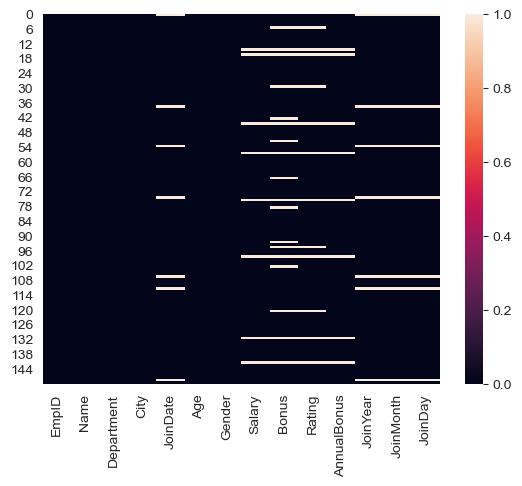

In [275]:
# Your code here
sns.heatmap(emp.isnull())

**Q6.2** Create `emp_dropped` by dropping any row that has **at least one** missing value. Compare its shape to the original.

In [271]:
# Your code here
emp_drooped = emp.dropna()
emp_drooped.shape

(125, 14)

**Q6.3** Fill missing `Bonus` values with `0`.

In [274]:
emp["Bonus"].fillna(0)

0       2625.0
1      11314.0
2       8973.0
3       9577.0
4       9070.0
        ...   
145     6941.0
146    18770.0
147    12555.0
148    14081.0
149     7819.0
Name: Bonus, Length: 150, dtype: float64

**Q6.4** Fill missing `Rating` values with the **column mean** (rounded to 1 decimal).

In [139]:
# Your code here


**Q6.5** Sort `sales_q1` by `OrderDate` and forward-fill any missing `Price` values (simulate one first: set 3 random `Price` values to `NaN`, then ffill).

In [141]:
# Your code here


**Q6.6** Fill missing `Salary` with the department-wise mean salary, and missing `Bonus` with `0` — both in a **single** `fillna()`-based approach.

In [140]:
# Your code here


---
## 7. Aggregation and Group By

One of the most common interview topics — practice `.groupby()` with single and multiple aggregations.

**Q7.1** Group `emp` by `Department` and find the **average Salary** per department.

In [ ]:
# Your code here


**Q7.2** Group by `Department` and compute `mean`, `max`, and `count` of `Salary` in one call using `.agg()`.

In [ ]:
# Your code here


**Q7.3** Group by `Department` **and** `City`, and count the number of employees in each group.

In [ ]:
# Your code here


**Q7.4** Find which department has the **highest average Salary**.

In [ ]:
# Your code here


**Q7.5** Use **named aggregation** to build a summary table with columns `avg_salary`, `max_bonus`, `emp_count` per department.

In [ ]:
# Your code here


**Q7.6** Using `sales_q1`, compute a new column `Revenue = Quantity * Price`, then find **total Revenue per Region**.

In [ ]:
# Your code here


---
## 8. Concatenate & Merge DataFrames (JOINs)

`sales_q1` and `sales_q2` have identical columns (good for `concat`). `departments.csv` intentionally does **not** include the `'Support'` department, and `sales` data intentionally contains a couple of `EmpID`s that don't exist in `employees.csv` — great for practicing different join types.

**Q8.1** Concatenate `sales_q1` and `sales_q2` (stacked vertically) into `sales_all`. Reset the index.

In [143]:
# Your code here


**Q8.2** Merge `emp` with `dept` on `Department` using an **inner join** to attach `Location` and `Budget`. Call it `emp_dept_inner`. How many rows are dropped compared to `emp`, and why?

In [ ]:
# Your code here
emp_dept_inner = pd.merge(emp,dept,on = "Department",how="inner")
print(emp.shape,dept.shape,emp_dept_inner.shape)

**Q8.3** Now perform a **left join** so that **all** employees are kept, even if their department has no match in `dept` (those rows will have `NaN` for `Location`/`Budget`).

In [ ]:
# Your code here


**Q8.4** Merge `sales_all` with `emp` on `EmpID` to attach `Name` and `Department` of the employee who made each sale. Use an inner join and check how many sales rows are dropped because of the invalid `EmpID`s (9998/9999) planted in the data.

In [ ]:
# Your code here


**Q8.5** Create two small DataFrames with the same index (e.g. `EmpID`) but different columns, and concatenate them **column-wise** (`axis=1`).

In [ ]:
# Your code here


**Q8.6** *(Interview favorite)* Merge `emp` and `dept` on `Department` using `how='outer'`. Identify rows that came **only** from `emp` and rows that came **only** from `dept` using the `indicator=True` argument.

In [ ]:
# Your code here


---
## 9. Data Visualization — Matplotlib & Seaborn

Turn the aggregations you've already built into charts. This is where pandas analysis meets storytelling — a skill interviewers love to see.

**Q9.1** Plot a **bar chart** of average `Salary` per `Department` using matplotlib.

In [145]:
# Your code here
avg_sal= emp.groupby("Department")["Salary"].mean()
avg_sal

Department
Finance       76865.517241
HR            87260.125000
IT            85738.862069
Marketing    100811.105263
Sales         96671.945946
Support       83470.166667
Name: Salary, dtype: float64

<BarContainer object of 6 artists>

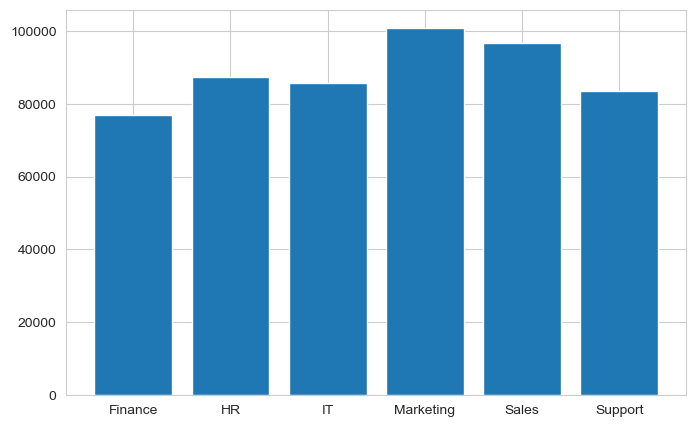

In [150]:
plt.figure(figsize=(8,5))
plt.bar(avg_sal.index,avg_sal.values)

**Q9.2** Plot a **histogram** of the `Age` distribution using `sns.histplot()` with a KDE curve.

In [152]:
# Your code here


**Q9.3** Plot a **boxplot** of `Salary` by `Department` using seaborn to compare spread and spot outliers.

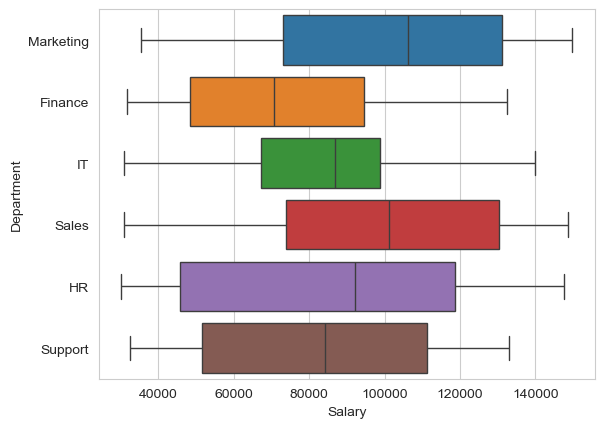

In [161]:
# Your code here

sns.boxplot(data=emp,x="Salary",y="Department",hue="Department")
plt.show()

**Q9.4** Using `sales_all` (with the `Revenue` column), plot a **line chart** of total revenue per month.

In [ ]:
# Your code here


**Q9.5** Plot a **scatter plot** of `Age` vs `Salary`, colored by `Department`, using seaborn.

In [ ]:
# Your code here


**Q9.6** Plot a **heatmap** of the correlation matrix for the numeric columns in `emp`.

In [ ]:
# Your code here


**Q9.7** Plot a **countplot** of the number of employees per `City` using seaborn, sorted from highest to lowest.

In [158]:
# Your code here
